# Bike Sharing Demand Prediction using Machine Learning

### Internship Project 2

**Submitted By:** Chirashree Mallick

**Domain:** Machine Learning Mentorship Program

**Organization:** 1Stop.ai

**Dataset Used:** Seoul Bike Sharing Demand Dataset

**Problem Type:** Regression

**Machine Learning Techniques / Algorithms Used:**
- Linear Regression
- Recursive Feature Elimination (RFE)
- Feature Scaling (MinMaxScaler)
- Correlation Analysis
- Regression Evaluation Metrics (R² Score)

**Objective:** To predict the number of rented bikes based on weather conditions, seasonal factors, and environmental variables using machine learning techniques.

## Problem Statement
The objective of this project is to predict the number of bikes rented based on environmental and seasonal factors such as temperature, humidity, rainfall, snowfall and visibility using Linear Regression.

## Importing Required Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE
from sklearn.metrics import r2_score

import statsmodels.api as sm

## Loading Dataset

In [2]:
df = pd.read_csv(
    "SeoulBikeData.csv",
    encoding='cp1252'
)

In [3]:
print(df.columns.tolist())

['Date', 'Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons', 'Holiday', 'Functioning Day']


In [4]:
print(df.select_dtypes(include='object').columns)

Index(['Date', 'Seasons', 'Holiday', 'Functioning Day'], dtype='object')


In [5]:
print(df.head())

         Date  Rented Bike Count  Hour  Temperature(°C)  Humidity(%)  \
0  01/12/2017                254     0             -5.2           37   
1  01/12/2017                204     1             -5.5           38   
2  01/12/2017                173     2             -6.0           39   
3  01/12/2017                107     3             -6.2           40   
4  01/12/2017                 78     4             -6.0           36   

   Wind speed (m/s)  Visibility (10m)  Dew point temperature(°C)  \
0               2.2              2000                      -17.6   
1               0.8              2000                      -17.6   
2               1.0              2000                      -17.7   
3               0.9              2000                      -17.6   
4               2.3              2000                      -18.6   

   Solar Radiation (MJ/m2)  Rainfall(mm)  Snowfall (cm) Seasons     Holiday  \
0                      0.0           0.0            0.0  Winter  No Holiday   


## Data Understanding

In [6]:
df.shape

(8760, 14)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   object 
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   object 
 12  Holiday                    8760 non-null   object 
 13  Functioning Day            8760 non-null   objec

In [8]:
df.describe()

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


In [9]:
df.isnull().sum()

Date                         0
Rented Bike Count            0
Hour                         0
Temperature(°C)              0
Humidity(%)                  0
Wind speed (m/s)             0
Visibility (10m)             0
Dew point temperature(°C)    0
Solar Radiation (MJ/m2)      0
Rainfall(mm)                 0
Snowfall (cm)                0
Seasons                      0
Holiday                      0
Functioning Day              0
dtype: int64

## Exploratory Data Analysis

### Distribution Plot

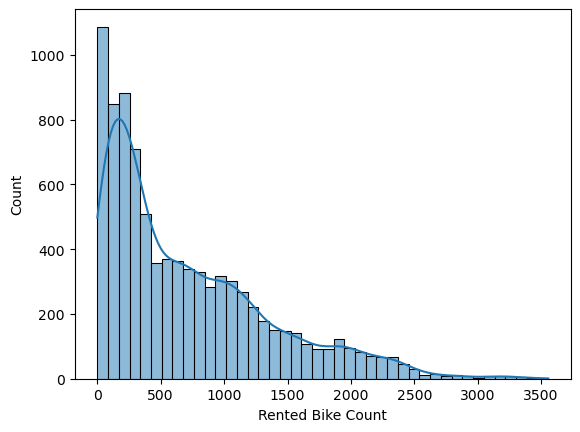

In [10]:
sns.histplot(df['Rented Bike Count'],kde=True)

plt.show()

### Temperature Distribution

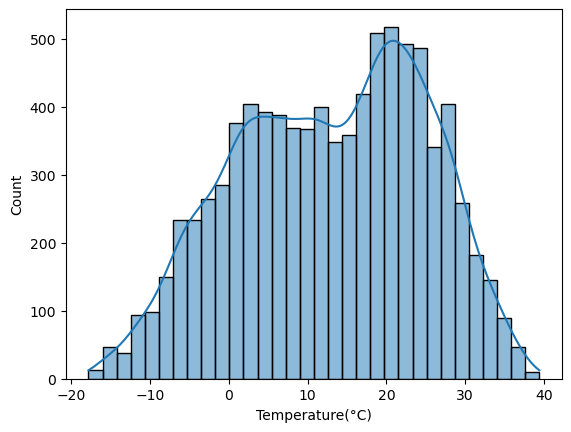

In [11]:
sns.histplot(df['Temperature(°C)'],kde=True)

plt.show()

### Humidity Distribution

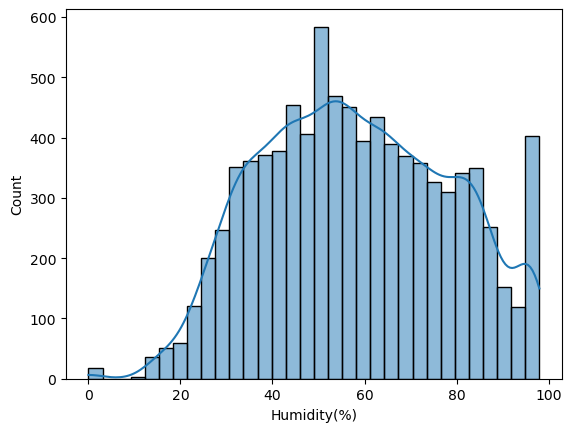

In [12]:
sns.histplot(df['Humidity(%)'],kde=True)

plt.show()

## Correlation Analysis

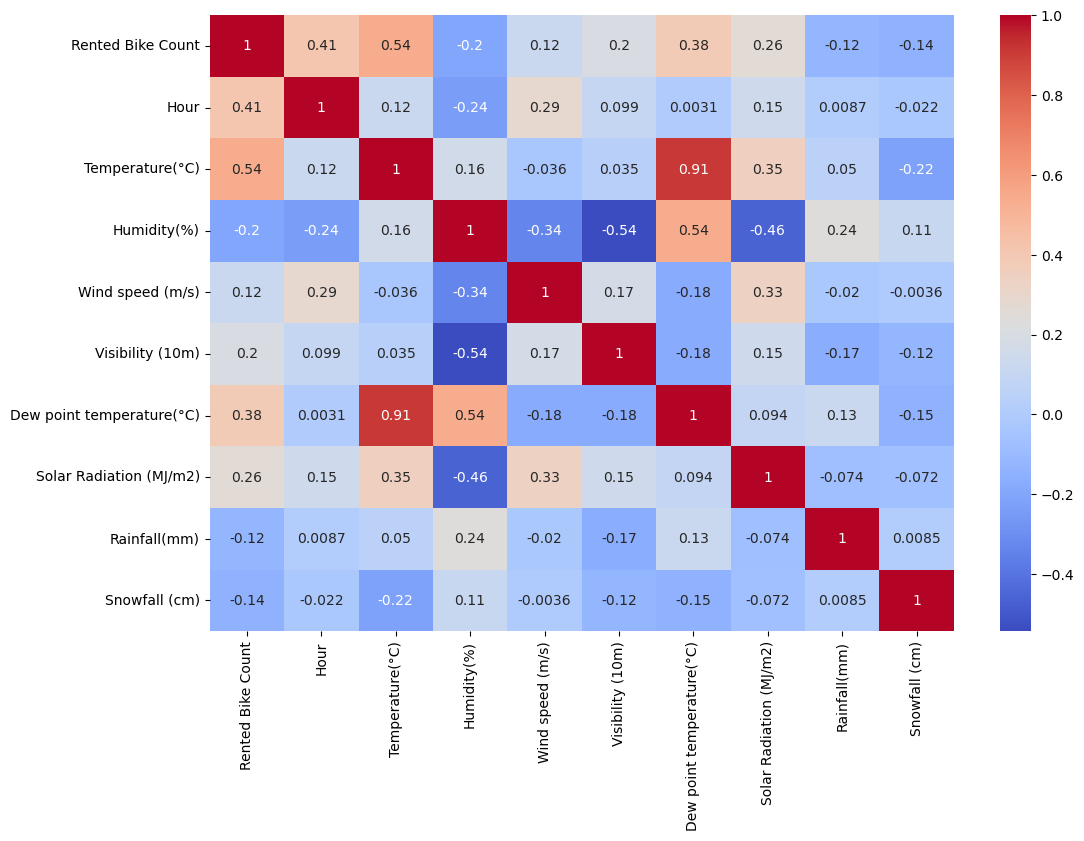

In [13]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.show()

## Data Preparation

In [14]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

df.drop('Date', axis=1, inplace=True)

In [15]:
df = pd.get_dummies(
    df,
    columns=[
        'Seasons',
        'Holiday',
        'Functioning Day'
    ],
    drop_first=True,
    dtype=int
)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Rented Bike Count          8760 non-null   int64  
 1   Hour                       8760 non-null   int64  
 2   Temperature(°C)            8760 non-null   float64
 3   Humidity(%)                8760 non-null   int64  
 4   Wind speed (m/s)           8760 non-null   float64
 5   Visibility (10m)           8760 non-null   int64  
 6   Dew point temperature(°C)  8760 non-null   float64
 7   Solar Radiation (MJ/m2)    8760 non-null   float64
 8   Rainfall(mm)               8760 non-null   float64
 9   Snowfall (cm)              8760 non-null   float64
 10  Month                      8760 non-null   int32  
 11  Day                        8760 non-null   int32  
 12  Seasons_Spring             8760 non-null   int64  
 13  Seasons_Summer             8760 non-null   int64

## Feature Scaling

In [17]:
scaler = MinMaxScaler()

num_cols = [
    'Temperature(°C)',
    'Humidity(%)',
    'Wind speed (m/s)',
    'Visibility (10m)',
    'Dew point temperature(°C)',
    'Solar Radiation (MJ/m2)',
    'Rainfall(mm)',
    'Snowfall (cm)',
    'Rented Bike Count'
]

df[num_cols] = scaler.fit_transform(df[num_cols])
print("Feature Scaling Applied Successfully")
df[num_cols].head()

Feature Scaling Applied Successfully


,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Rented Bike Count
0,0.220280,0.377551,0.297297,1.0,0.224913,0.0,0.0,0.0,0.071429
1,0.215035,0.387755,0.108108,1.0,0.224913,0.0,0.0,0.0,0.057368
2,0.206294,0.397959,0.135135,1.0,0.223183,0.0,0.0,0.0,0.048650
3,0.202797,0.408163,0.121622,1.0,0.224913,0.0,0.0,0.0,0.030090
4,0.206294,0.367347,0.310811,1.0,0.207612,0.0,0.0,0.0,0.021935


## Train Test Split

In [18]:
X = df.drop(
    'Rented Bike Count',
    axis=1
)

y = df['Rented Bike Count']

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (6132, 16)
X_test Shape: (2628, 16)
y_train Shape: (6132,)
y_test Shape: (2628,)


## Feature Selection using RFE

In [19]:
lr = LinearRegression()

rfe = RFE(
    estimator=lr,
    n_features_to_select=10
)

rfe.fit(
    X_train,
    y_train
)

selected_features = X_train.columns[
    rfe.support_
]

selected_features

Index(['Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)',
       'Dew point temperature(°C)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)',
       'Snowfall (cm)', 'Seasons_Summer', 'Seasons_Winter',
       'Functioning Day_Yes'],
      dtype='object')

## Model Building

In [20]:
X_train_rfe = X_train[
    selected_features
]

X_train_sm = sm.add_constant(
    X_train_rfe
)

model = sm.OLS(
    y_train,
    X_train_sm
).fit()

print("Training R2:", model.rsquared)
print("Adjusted R2:", model.rsquared_adj)

print(model.summary())

Training R2: 0.469437371896694
Adjusted R2: 0.4685705811303106
                            OLS Regression Results                            
Dep. Variable:      Rented Bike Count   R-squared:                       0.469
Model:                            OLS   Adj. R-squared:                  0.469
Method:                 Least Squares   F-statistic:                     541.6
Date:                Sun, 07 Jun 2026   Prob (F-statistic):               0.00
Time:                        19:21:19   Log-Likelihood:                 3691.5
No. Observations:                6132   AIC:                            -7361.
Df Residuals:                    6121   BIC:                            -7287.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------

## Prediction on Test Data

In [21]:
X_test_rfe = X_test[
    selected_features
]

X_test_sm = sm.add_constant(
    X_test_rfe
)

y_pred = model.predict(
    X_test_sm
)
print(y_pred[:10])

6056    0.294004
5556    0.320526
5990    0.374171
7674    0.319107
3319    0.195872
5761    0.299832
5972    0.372564
8758    0.189953
6079    0.298149
7177    0.306954
dtype: float64


## Model Evaluation

In [22]:
r2 = r2_score(
    y_test,
    y_pred
)
print(y_pred[:10])
print("R2 Score:",r2)

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)

6056    0.294004
5556    0.320526
5990    0.374171
7674    0.319107
3319    0.195872
5761    0.299832
5972    0.372564
8758    0.189953
6079    0.298149
7177    0.306954
dtype: float64
R2 Score: 0.47183690038428827
MAE: 0.09603792832019276
MSE: 0.017116147484096622


# Best Model Summary

In [23]:
print("Model Used: Linear Regression")
print("R2 Score:",r2)

Model Used: Linear Regression
R2 Score: 0.47183690038428827


## Actual vs Predicted Values

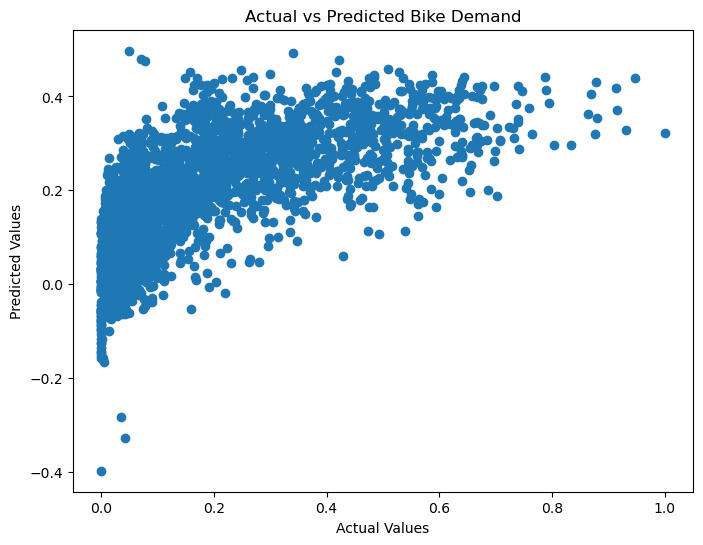

In [24]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted Bike Demand")

plt.show()

## Conclusion

In this project, a Linear Regression model was developed to predict bike rental demand using the Seoul Bike Sharing dataset. 

Data preprocessing, exploratory data analysis, feature scaling, feature selection using RFE, and model building were performed successfully. Weather conditions, seasonal factors, temperature, humidity, and rainfall were identified as important variables influencing bike rental demand. 

The model was evaluated using the R² metric and demonstrated the practical application of machine learning techniques in demand forecasting and transportation planning.